In [9]:
import torch
from torch.utils.data import DataLoader,Dataset,random_split
import pandas as pd
import os
import numpy as np
import random
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
random.seed(42)
def oneHotEncoding(combination):
    '''
    This function will turn molecule combinations into a one-hot encoded vector

    Inputs
    ------
    combination: Tuple containing the abundances of the molecules in this order: "O2","N2","H2","CO2","H2O","CH4","NH3"

    Returns
    -------
    vector: One-hot encoded vector of 1's and 0's
    '''

    #The order of the molecules are: "O2","N2","H2","CO2","H2O","CH4","NH3"
    vector=[0.]*7
    for i,abundance in enumerate(combination):
        #At what point should a molecule be considered present? I don't know need to think about that
        if abundance>0.001:
            vector[i]=1.0
    return torch.tensor(vector) 

def getLabel(filePath,specialMolecules=False):
    configFolder=r"C:\Users\Tristan\Downloads\HyPCAR3\configFiles"

    filePath=filePath.removesuffix(".csv")
    configFilePath=os.path.join(configFolder,filePath)
    configFilePath+=".txt"

    lines=[]
    with open(configFilePath) as f:
        for line in f:
            lines.append(line)


    abundances=lines[54]
    abundances=abundances.removeprefix("<ATMOSPHERE-LAYER-1>")
    abundances=abundances.split(",")
    
    if not specialMolecules:
        abundances=list(map(float,abundances[2:]))#Remove temperature profile information
        label=oneHotEncoding(abundances)
        return label
    else:
        abundances=list(map(float,abundances[2:9]))#Only gets target values, not background moolecules or 
        label=oneHotEncoding(abundances)
        return label


class detectionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv1d(in_channels=2, out_channels=128, kernel_size=5, stride=2)
        self.bn1=nn.BatchNorm1d(128)
        self.pool1=nn.MaxPool1d(2)

        self.conv2=nn.Conv1d(in_channels=128,out_channels=128,kernel_size=5,stride=2)
        self.bn2=nn.BatchNorm1d(128)
        self.pool2=nn.MaxPool1d(2)

        self.conv3=nn.Conv1d(in_channels=128,out_channels=64,kernel_size=3,stride=2)
        self.bn3=nn.BatchNorm1d(64)
        self.pool3=nn.MaxPool1d(2)

        self.conv4=nn.Conv1d(in_channels=64,out_channels=32,kernel_size=2,stride=2)
        self.bn4=nn.BatchNorm1d(32)
        self.pool4=nn.MaxPool1d(2)

        self.dropout1=nn.Dropout(0.4)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        

        self.fc1=nn.Linear(32,128)
        self.dropout2=nn.Dropout(0.75)
        self.fc2=nn.Linear(128,64)
        self.fc3=nn.Linear(64,7)#7 molecule present

    def forward(self,x):
        # Permute dimensions to [batch_size, channels, sequence_length]
        x=x.permute(0, 2, 1)
        x=F.relu(self.bn1(self.conv1(x)))
        x=self.pool1(x)

        x=F.relu(self.bn2(self.conv2(x)))
        x=self.pool2(x)

        x=F.relu(self.bn3(self.conv3(x)))
        x=self.pool3(x)

        x=F.relu(self.bn4(self.conv4(x)))
        x=self.pool4(x)

        x=self.dropout1(x)

        x=self.global_pool(x)
        x=torch.flatten(x,1)

        x=F.relu(self.fc1(x))
        x=self.dropout2(x)
        
        x=F.relu(self.fc2(x))
        x=torch.sigmoid(self.fc3(x))
        
        return x
    
def wavelengthFilter(string):
    '''
    This function removes the um suffix from the wavelength data.

    Inputs
    ------
    string: A string to remove um from.

    Returns
    -------
    string: A float
    '''
    string=string.removesuffix(" um")
    return float(string)
class customDataset(Dataset):
    def __init__(self,samples):#samples contain a listt of all file paths
        self.samples=samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,index):
        filePath,label=self.samples[index]

        #Get config file for this sample
        configFilePath=r"C:\Users\Tristan\Downloads\HyPCAR3\configFiles"

        fileName=os.path.basename(filePath)
        fileName=fileName.removesuffix(".csv")
        configFilePath+=fileName+".txt"


        #Extract data from file
        data=pd.read_csv(filePath)
        wavelength=list(map(wavelengthFilter,data.iloc[:,0]))#Removes um from wavelength data
        transmittance=list(data.iloc[:,1])

        combinedData=torch.tensor(list(zip(wavelength, transmittance)), dtype=torch.float32)

        return combinedData,label,configFilePath
random.seed(42)

testingData=[]
testSplit=0.15
print("Running")
for atmosphereType in ["A","B","C","None"]:
    curFolderPath=r"C:\Users\Tristan\Downloads\HyPCAR3\data\\"+atmosphereType

    files=[]
    for path in os.listdir(curFolderPath):
        #Need to get molecule abundances as well, this means that for each file, I need to go to the config file
        #Then extract the abundances there
        #This is how I will get the one-hot vector for the presence
        #Will just write a functionn
        if atmosphereType=="None":
            #Gett labels in a special way
            label=getLabel(path,True)
        else:
            label=getLabel(path)
        files.append((os.path.join(curFolderPath,path),label))

    random.shuffle(files)

    testingSamples=[]
    for i,data in enumerate(files):
        path,label=data[0],data[1]
        if i<(len(files)*testSplit):#Adds testing data
            testingSamples.append((path,label))
        else:
            break
    testingData.extend(testingSamples)


print("Loaded data")
random.shuffle(testingData)
testingDataset=customDataset(testingData)
testingDataloader=DataLoader(testingDataset,batch_size=32,shuffle=True)#Testing data loader

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

detect=detect=detectionModel()
detect.load_state_dict(torch.load(r"C:\Users\Tristan\Downloads\HyPCAR3\flexibleDetectionModel.pt",weights_only=True))
detect=detect.to(device)

detect.eval()
    
trueLabels=[]
predictions=[]
probs=[]
with torch.no_grad():
    for batch in testingDataloader:
        data,labels,config=batch

    
        data=data.to(device)
        labels=labels.to(device)

        outputs=detect(data)
        predicted=(outputs>0.5).int()

        trueLabels.append(labels.cpu().numpy())
        predictions.append(predicted.cpu().numpy())
        probs.append(outputs.cpu().numpy())

trueLabels= np.array(trueLabels)
predictions = np.array(predictions)
probs=np.array(probs)
trueLabels = np.concatenate(trueLabels, axis=0)  # Shape (720, 7)
predictions = np.concatenate(predictions, axis=0) 
probs=np.concatenate(probs,axis=0)

Running
Loaded data


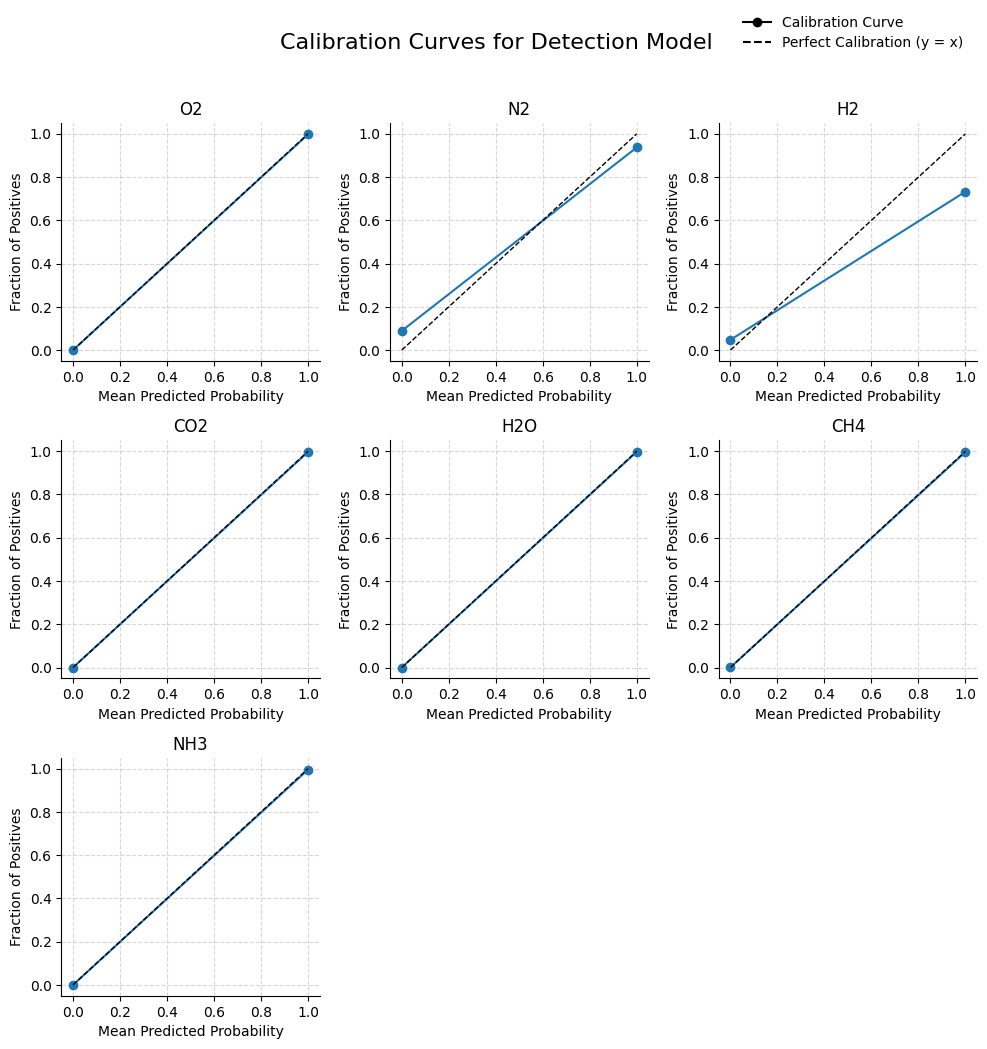

In [ ]:
from sklearn.calibration import calibration_curve


classes = ["O2", "N2", "H2", "CO2", "H2O", "CH4", "NH3"]
n_classes = trueLabels.shape[1]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    ax = axes[i]
    prob_true, prob_pred = calibration_curve(trueLabels[:, i], predictions[:, i], n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=f'{cls}')
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(cls)
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(classes), len(axes)):
    axes[j].axis('off')

fig.legend(
    handles=[
        plt.Line2D([0], [0], marker='o', color='black', label="Calibration Curve"),
        plt.Line2D([0], [0], linestyle="--", color='black', label="Perfect Calibration (y = x)")
    ],
    loc="upper right", fontsize=10, frameon=False, bbox_to_anchor=(0.98, 1.05)
)


fig.suptitle("Calibration Curves for Detection Model", fontsize=16, y=1.02)
plt.tight_layout(pad=1.0)
plt.show()